# 17 — Cross-Dataset Evaluation (Logistic Regression & SVM)

> **Mục tiêu:** Thực hiện đánh giá hiệu năng chéo tập dữ liệu (Cross-dataset Evaluation) cho hai mô hình **Logistic Regression** và **Support Vector Machine (SVM)** đã được huấn luyện trên hai tập dữ liệu **ISOT** và **WELFake**.

Chúng ta thực hiện đánh giá dưới 2 kịch bản:
1. **Đánh giá Nội miền (In-domain Evaluation)**: Huấn luyện trên Train Set A ➔ đánh giá trên Test Set A.
2. **Đánh giá Chéo miền (Cross-domain Evaluation)**: Huấn luyện trên Train Set A ➔ đánh giá trên Test Set B (sử dụng Vectorizer của A để biến đổi văn bản gốc của B).

In [1]:
import os
import time
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")

# Cấu hình đường dẫn
ROOT = Path('..').resolve()
DATA_DIR = ROOT / 'data'
MODELS_DIR = ROOT / 'models'
REPORTS_DIR = ROOT / 'reports'
REPORTS_DIR.mkdir(exist_ok=True)

In [2]:
# 1. Load các mô hình và Vectorizers
print("Loading models and vectorizers...")
isot_vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")
wf_vectorizer = joblib.load(MODELS_DIR / "tfidf_vectorizer_welfake.pkl")

isot_lr = joblib.load(MODELS_DIR / "lr_model.pkl")
wf_lr = joblib.load(MODELS_DIR / "lr_welfake_model.pkl")

isot_svm = joblib.load(MODELS_DIR / "svm_model.pkl")
wf_svm = joblib.load(MODELS_DIR / "svm_welfake_model.pkl")

print("Loaded successfully!")

Loading models and vectorizers...
Loaded successfully!


In [3]:
# 2. Tái cấu trúc tập test raw từ CSV gốc
print("Loading raw datasets...")
isot_df = pd.read_csv(DATA_DIR / "preprocessed_isot_full.csv").dropna(subset=["processed_text", "label"]).reset_index(drop=True)
wf_df = pd.read_csv(DATA_DIR / "processed/preprocessed_welfake_full.csv").dropna(subset=["processed_text"]).reset_index(drop=True)

# Chia tập ISOT đúng tham số
X_isot = isot_df["processed_text"].astype(str)
y_isot = isot_df["label"].astype(int)
_, X_temp_isot, _, y_temp_isot = train_test_split(X_isot, y_isot, test_size=0.30, random_state=42, stratify=y_isot)
_, X_test_isot, _, y_test_isot = train_test_split(X_temp_isot, y_temp_isot, test_size=0.50, random_state=42, stratify=y_temp_isot)

# Chia tập WELFake đúng tham số
X_wf = wf_df["processed_text"].astype(str)
y_wf = wf_df["label"].astype(int)
_, X_temp_wf, _, y_temp_wf = train_test_split(X_wf, y_wf, test_size=0.30, random_state=42, stratify=y_wf)
_, X_test_wf, _, y_test_wf = train_test_split(X_temp_wf, y_temp_wf, test_size=0.50, random_state=42, stratify=y_temp_wf)

print(f"ISOT Test size: {len(X_test_isot):,} | WELFake Test size: {len(X_test_wf):,}")

Loading raw datasets...
ISOT Test size: 5,798 | WELFake Test size: 10,812


## 3. Đánh giá Mô hình Logistic Regression

In [4]:
# A. In-domain Evaluation
print("--- LOGISTIC REGRESSION: IN-DOMAIN EVALUATION ---")
# ISOT on ISOT Test
X_test_isot_tfidf_isot = isot_vectorizer.transform(X_test_isot)
y_pred_lr_isot_isot = isot_lr.predict(X_test_isot_tfidf_isot)
print("\n1. ISOT Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_lr_isot_isot, digits=4))

# WELFake on WELFake Test
X_test_wf_tfidf_wf = wf_vectorizer.transform(X_test_wf)
y_pred_lr_wf_wf = wf_lr.predict(X_test_wf_tfidf_wf)
print("\n2. WELFake Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_lr_wf_wf, digits=4))

# B. Cross-domain Evaluation
print("\n--- LOGISTIC REGRESSION: CROSS-DOMAIN EVALUATION ---")
# ISOT Model on WELFake Test
X_test_wf_tfidf_isot = isot_vectorizer.transform(X_test_wf)
y_pred_lr_isot_wf = isot_lr.predict(X_test_wf_tfidf_isot)
print("\n3. ISOT Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_lr_isot_wf, digits=4))

# WELFake Model on ISOT Test
X_test_isot_tfidf_wf = wf_vectorizer.transform(X_test_isot)
y_pred_lr_wf_isot = wf_lr.predict(X_test_isot_tfidf_wf)
print("\n4. WELFake Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_lr_wf_isot, digits=4))

--- LOGISTIC REGRESSION: IN-DOMAIN EVALUATION ---

1. ISOT Model on ISOT Test:
              precision    recall  f1-score   support

           0     0.9931    0.9965    0.9948      3180
           1     0.9958    0.9916    0.9937      2618

    accuracy                         0.9943      5798
   macro avg     0.9944    0.9941    0.9943      5798
weighted avg     0.9943    0.9943    0.9943      5798


2. WELFake Model on WELFake Test:
              precision    recall  f1-score   support

           0     0.9433    0.9401    0.9417      5255
           1     0.9435    0.9466    0.9450      5557

    accuracy                         0.9434     10812
   macro avg     0.9434    0.9433    0.9433     10812
weighted avg     0.9434    0.9434    0.9434     10812


--- LOGISTIC REGRESSION: CROSS-DOMAIN EVALUATION ---

3. ISOT Model on WELFake Test:
              precision    recall  f1-score   support

           0     0.9264    0.7638    0.8373      5255
           1     0.8085    0.9426    

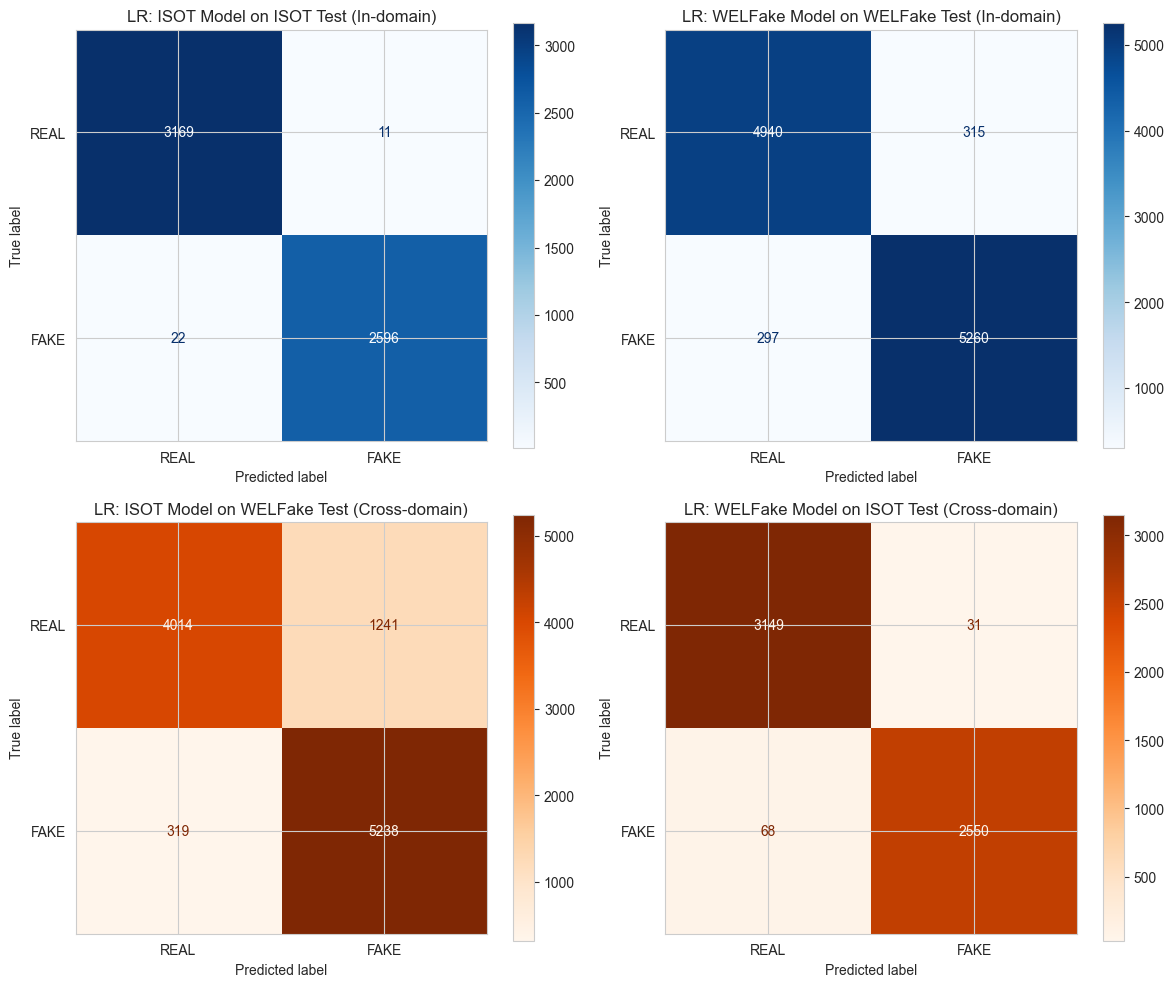

In [5]:
# Vẽ ma trận nhầm lẫn cho Logistic Regression
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. ISOT Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_lr_isot_isot, cmap='Blues', ax=axes[0, 0], display_labels=['REAL', 'FAKE'])
axes[0, 0].set_title("LR: ISOT Model on ISOT Test (In-domain)")

# 2. WELFake Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_lr_wf_wf, cmap='Blues', ax=axes[0, 1], display_labels=['REAL', 'FAKE'])
axes[0, 1].set_title("LR: WELFake Model on WELFake Test (In-domain)")

# 3. ISOT Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_lr_isot_wf, cmap='Oranges', ax=axes[1, 0], display_labels=['REAL', 'FAKE'])
axes[1, 0].set_title("LR: ISOT Model on WELFake Test (Cross-domain)")

# 4. WELFake Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_lr_wf_isot, cmap='Oranges', ax=axes[1, 1], display_labels=['REAL', 'FAKE'])
axes[1, 1].set_title("LR: WELFake Model on ISOT Test (Cross-domain)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'lr_cross_eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Đánh giá Mô hình SVM (LinearSVC)

In [6]:
# A. In-domain Evaluation
print("--- SVM: IN-DOMAIN EVALUATION ---")
# ISOT on ISOT Test
y_pred_svm_isot_isot = isot_svm.predict(X_test_isot_tfidf_isot)
print("\n1. ISOT Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_svm_isot_isot, digits=4))

# WELFake on WELFake Test
y_pred_svm_wf_wf = wf_svm.predict(X_test_wf_tfidf_wf)
print("\n2. WELFake Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_svm_wf_wf, digits=4))

# B. Cross-domain Evaluation
print("\n--- SVM: CROSS-DOMAIN EVALUATION ---")
# ISOT Model on WELFake Test
y_pred_svm_isot_wf = isot_svm.predict(X_test_wf_tfidf_isot)
print("\n3. ISOT Model on WELFake Test:")
print(classification_report(y_test_wf, y_pred_svm_isot_wf, digits=4))

# WELFake Model on ISOT Test
y_pred_svm_wf_isot = wf_svm.predict(X_test_isot_tfidf_wf)
print("\n4. WELFake Model on ISOT Test:")
print(classification_report(y_test_isot, y_pred_svm_wf_isot, digits=4))

--- SVM: IN-DOMAIN EVALUATION ---

1. ISOT Model on ISOT Test:
              precision    recall  f1-score   support

           0     0.9953    0.9965    0.9959      3180
           1     0.9958    0.9943    0.9950      2618

    accuracy                         0.9955      5798
   macro avg     0.9955    0.9954    0.9955      5798
weighted avg     0.9955    0.9955    0.9955      5798


2. WELFake Model on WELFake Test:
              precision    recall  f1-score   support

           0     0.9460    0.9408    0.9434      5255
           1     0.9443    0.9493    0.9468      5557

    accuracy                         0.9452     10812
   macro avg     0.9452    0.9450    0.9451     10812
weighted avg     0.9452    0.9452    0.9451     10812


--- SVM: CROSS-DOMAIN EVALUATION ---

3. ISOT Model on WELFake Test:
              precision    recall  f1-score   support

           0     0.9259    0.7633    0.8368      5255
           1     0.8080    0.9422    0.8700      5557

    accuracy  

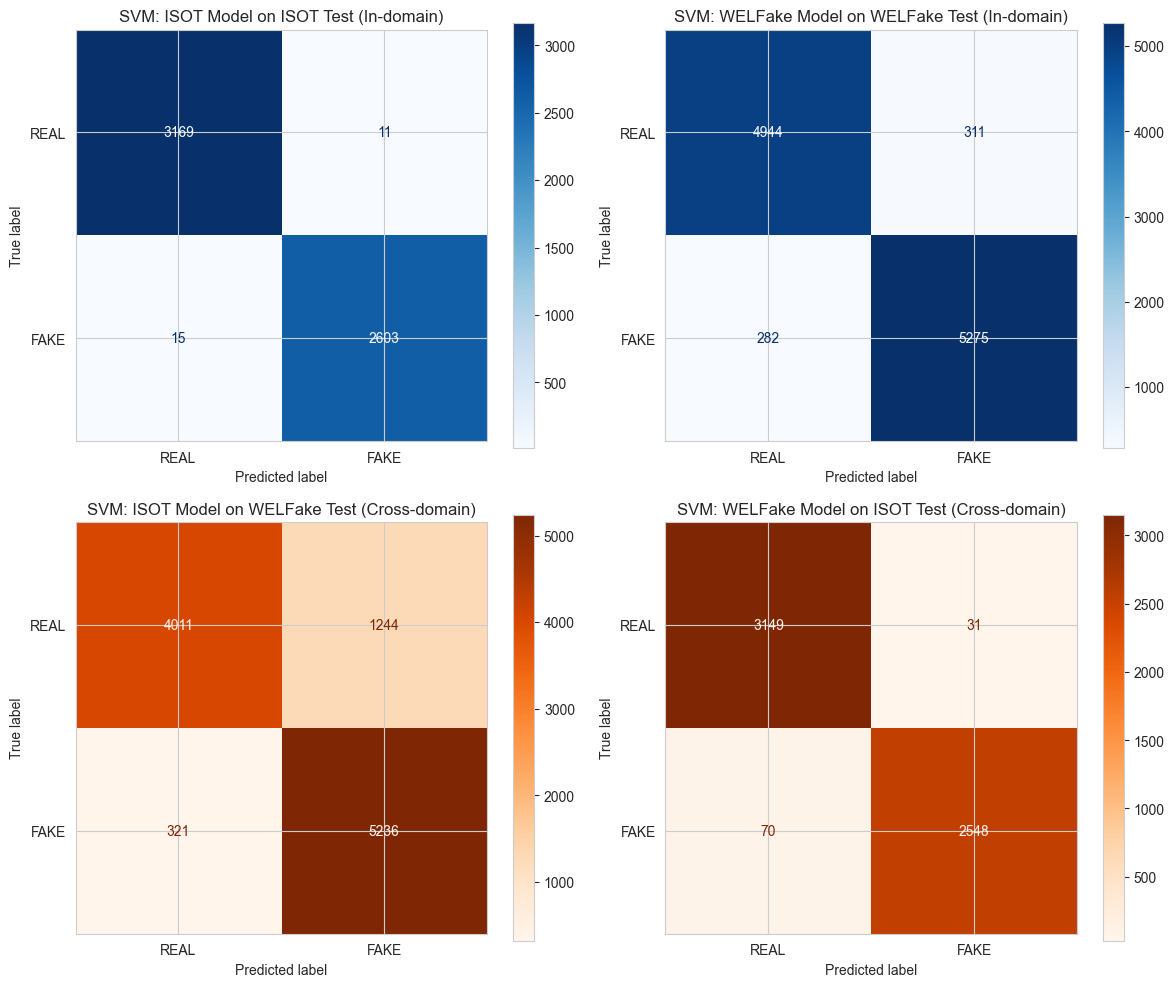

In [7]:
# Vẽ ma trận nhầm lẫn cho SVM
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. ISOT Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_svm_isot_isot, cmap='Blues', ax=axes[0, 0], display_labels=['REAL', 'FAKE'])
axes[0, 0].set_title("SVM: ISOT Model on ISOT Test (In-domain)")

# 2. WELFake Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_svm_wf_wf, cmap='Blues', ax=axes[0, 1], display_labels=['REAL', 'FAKE'])
axes[0, 1].set_title("SVM: WELFake Model on WELFake Test (In-domain)")

# 3. ISOT Model on WELFake Test
ConfusionMatrixDisplay.from_predictions(y_test_wf, y_pred_svm_isot_wf, cmap='Oranges', ax=axes[1, 0], display_labels=['REAL', 'FAKE'])
axes[1, 0].set_title("SVM: ISOT Model on WELFake Test (Cross-domain)")

# 4. WELFake Model on ISOT Test
ConfusionMatrixDisplay.from_predictions(y_test_isot, y_pred_svm_wf_isot, cmap='Oranges', ax=axes[1, 1], display_labels=['REAL', 'FAKE'])
axes[1, 1].set_title("SVM: WELFake Model on ISOT Test (Cross-domain)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / 'svm_cross_eval_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Tổng hợp Kết quả và So sánh

In [8]:
# Helper function to calculate metrics
def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted')
    return [acc, prec, rec, f1]

results = {
    'LR: ISOT -> ISOT (In-domain)': get_metrics(y_test_isot, y_pred_lr_isot_isot),
    'LR: WELFake -> WELFake (In-domain)': get_metrics(y_test_wf, y_pred_lr_wf_wf),
    'LR: ISOT -> WELFake (Cross-domain)': get_metrics(y_test_wf, y_pred_lr_isot_wf),
    'LR: WELFake -> ISOT (Cross-domain)': get_metrics(y_test_isot, y_pred_lr_wf_isot),
    'SVM: ISOT -> ISOT (In-domain)': get_metrics(y_test_isot, y_pred_svm_isot_isot),
    'SVM: WELFake -> WELFake (In-domain)': get_metrics(y_test_wf, y_pred_svm_wf_wf),
    'SVM: ISOT -> WELFake (Cross-domain)': get_metrics(y_test_wf, y_pred_svm_isot_wf),
    'SVM: WELFake -> ISOT (Cross-domain)': get_metrics(y_test_isot, y_pred_svm_wf_isot)
}

df_results = pd.DataFrame.from_dict(results, orient='index', columns=['Accuracy', 'Precision', 'Recall', 'F1-Score (weighted)'])
print("=== BẢNG SO SÁNH HIỆU NĂNG CHÉO MIỀN ===")
print(df_results.round(4))

# Save results to CSV
df_results.to_csv(REPORTS_DIR / 'cross_dataset_eval_comparison.csv')

=== BẢNG SO SÁNH HIỆU NĂNG CHÉO MIỀN ===
                                     Accuracy  Precision  Recall  \
LR: ISOT -> ISOT (In-domain)           0.9943     0.9943  0.9943   
LR: WELFake -> WELFake (In-domain)     0.9434     0.9434  0.9434   
LR: ISOT -> WELFake (Cross-domain)     0.8557     0.8658  0.8557   
LR: WELFake -> ISOT (Cross-domain)     0.9829     0.9830  0.9829   
SVM: ISOT -> ISOT (In-domain)          0.9955     0.9955  0.9955   
SVM: WELFake -> WELFake (In-domain)    0.9452     0.9452  0.9452   
SVM: ISOT -> WELFake (Cross-domain)    0.8553     0.8653  0.8553   
SVM: WELFake -> ISOT (Cross-domain)    0.9826     0.9826  0.9826   

                                     F1-Score (weighted)  
LR: ISOT -> ISOT (In-domain)                      0.9943  
LR: WELFake -> WELFake (In-domain)                0.9434  
LR: ISOT -> WELFake (Cross-domain)                0.8543  
LR: WELFake -> ISOT (Cross-domain)                0.9829  
SVM: ISOT -> ISOT (In-domain)                     0

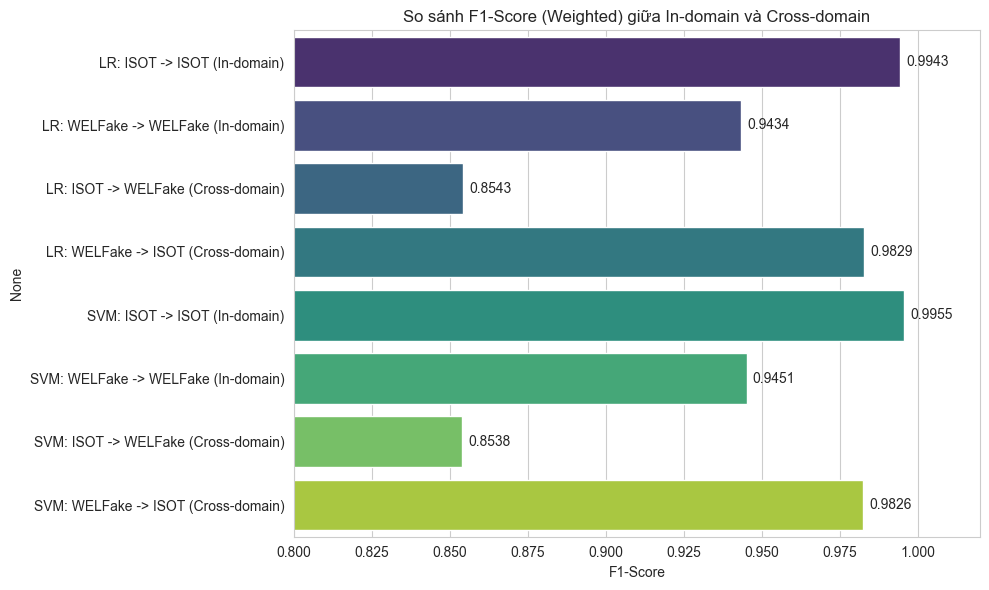

In [9]:
# Vẽ biểu đồ cột so sánh F1-Score
plt.figure(figsize=(10, 6))
sns.barplot(x=df_results['F1-Score (weighted)'], y=df_results.index, palette='viridis')
plt.title("So sánh F1-Score (Weighted) giữa In-domain và Cross-domain")
plt.xlabel("F1-Score")
plt.xlim(0.8, 1.02)
for index, value in enumerate(df_results['F1-Score (weighted)']):
    plt.text(value + 0.002, index, f"{value:.4f}", va='center')
plt.tight_layout()
plt.savefig(REPORTS_DIR / 'cross_eval_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()